# Fine-tuning GridSFM-Open on case6470 (OPFData few-shot study)

Demonstrates fine-tuning the released `gridsfm_open_v1.1.pt` checkpoint on `pglib_opf_case6470_rte` from the OPFData dataset.

Workflow:
1. (Optional) Download OPFData case6470 if not cached locally.
2. Load the release checkpoint.
3. **0-shot eval** on test fulltop + n-1 (MAE + cost MAPE).
4. **Fine-tune** for 10 epochs with **16 / 104 / 1000** training samples (multiples of `batch_size=8`), each starting fresh from the release weights.
5. Plot per-epoch train+val loss curves.
6. Eval each FT'd model on held-out test fulltop + n-1.
7. Side-by-side summary table.

All FT-side functionality lives in the `gridsfm` package: `compute_loss`, `eval_pass`, `finetune_opfdata`, `OPFDataAdapterDataset`, `SyntheticMixedDataset`. Single-GPU only.

## 1. Setup

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from torch_geometric.loader import DataLoader

from gridsfm import (
    load_model,
    OPFDataAdapterDataset, SyntheticMixedDataset,
    eval_pass, finetune_opfdata,
)
from gridsfm.cycle_basis import CycleBasisCache, prepare_for_grid_transformer_
from gridsfm.pe_features import LaplacianFactorizationCache, attach_pe_features_

# Resolve cwd to model/ so relative paths below work whether the kernel
# was started from model/, examples/, or somewhere else (e.g. via
# papermill / nbconvert).
_cwd = Path.cwd()
while _cwd != _cwd.parent and not (_cwd / 'checkpoints').is_dir():
    _cwd = _cwd.parent
if (_cwd / 'checkpoints').is_dir():
    os.chdir(_cwd)

# Paths (relative to model/)
RELEASE_CKPT = 'checkpoints/gridsfm_open_v1.1.pt'
OPFDATA_ROOT = '/data/OPF/opfdata_pyg_train'  # change to your local cache
CASE = 'pglib_opf_case6470_rte'

# Hardware
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
print(f'device = {device}  cwd = {Path.cwd()}')

device = cuda:0  cwd = /home/weiwya/GridSFM-Staging/model


## 2. (Optional) Download OPFData

OPFData is hosted by Google DeepMind on Google Cloud Storage. The first time you use a case, `OPFDataAdapterDataset` (via PyG's `OPFDataset`) downloads the raw chunks and processes them into a local cache. The cell below is **idempotent**: it short-circuits if the cache directory exists, otherwise it triggers the download.

In [2]:
FULLTOP_DIR = Path(OPFDATA_ROOT) / 'dataset_release_1' / CASE
N1_DIR      = Path(OPFDATA_ROOT) / 'dataset_release_1_nminusone' / CASE

def ensure_opfdata():
    """Download case6470 fulltop + n-1 chunks if absent."""
    if FULLTOP_DIR.exists() and N1_DIR.exists():
        print(f'[data] cache present, skipping download')
        return
    print(f'[data] downloading {CASE} (first time, ~10-30 min)...')
    for variant in ('fulltop', 'n1'):
        _ = OPFDataAdapterDataset(
            root=OPFDATA_ROOT, case_name=CASE,
            variant=variant, split='train', n_graphs=1,
        )
    print(f'[data] download complete')

ensure_opfdata()

[data] cache present, skipping download


## 3. Load the release checkpoint

`load_model` verifies the SHA-256 hash in `metadata.hash` and rebuilds the backbone from pinned hyperparameters. The release ckpt contains only `{state_dict, metadata}`: no optimizer / scheduler / args.

In [3]:
_base = load_model(RELEASE_CKPT, device=device)
# Snapshot the release weights so each FT round can restart from the same
# starting point (independent runs).
RELEASE_STATE = {k: v.detach().cpu().clone() for k, v in _base.state_dict().items()}
print(f'loaded {sum(p.numel() for p in _base.parameters())/1e6:.2f}M params')
del _base; torch.cuda.empty_cache() if device.type == 'cuda' else None

checkpoints/gridsfm_open_v1.1.pt: metadata.arch missing; building model from default hyperparameters. If the release was trained with non-default arch, the load will silently shape-adapt every layer.


loaded 15.15M params


## 4. Held-out data loaders

OPFData ships three splits per (case, variant): `train` (13.5k), `val` (750), `test` (750). We use BOTH val and test:

* `val_loader_ft`: fulltop **val** split, during-FT probe (per-epoch loss curve).
* `test_loader_ft` / `test_loader_n1`: fulltop / n-1 **test** splits, strict held-out final eval after each FT round.

No synth wrap on any of these; OPFData val/test are clean all-feasible OOD probes.

In [4]:
cb_cache = CycleBasisCache()
pe_cache = LaplacianFactorizationCache()

def transform(d):
    prepare_for_grid_transformer_(d, cache=cb_cache)
    attach_pe_features_(d, cache=pe_cache)
    return d

def make_loader(variant, split, n_graphs=750, batch_size=8):
    ds = OPFDataAdapterDataset(
        root=OPFDATA_ROOT, case_name=CASE,
        variant=variant, split=split, n_graphs=n_graphs,
        transform=transform,
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=False,
                      num_workers=2, persistent_workers=True), len(ds)

val_loader_ft,  n_val_ft = make_loader('fulltop', split='val')
test_loader_ft, n_ft     = make_loader('fulltop', split='test')
test_loader_n1, n_n1     = make_loader('n1',      split='test')
print(f'val fulltop  (during-FT probe): {n_val_ft} graphs')
print(f'test fulltop (final eval):      {n_ft} graphs')
print(f'test n-1     (final eval):      {n_n1} graphs')

val fulltop  (during-FT probe): 750 graphs
test fulltop (final eval):      750 graphs
test n-1     (final eval):      750 graphs


## 5. Eval helpers

In [5]:
def fmt_eval(name, m):
    return (
        f'{name:>22s}  cost_mape={m["cost_mape"]*100:6.2f}%  '
        f'pg_mae={m["pg_mae"]:.4f}  qg_mae={m["qg_mae"]:.4f}  '
        f'V_mae={m["V_mae"]:.4f}  theta_mae={m["theta_mae"]:.4f}  '
        f'brP_mae={m["brP_mae"]:.4f}  brQ_mae={m["brQ_mae"]:.4f}  '
        f'kcl_P={m["kcl_P_resid"]:.4f}  kcl_Q={m["kcl_Q_resid"]:.4f}  '
        f'therm_max={m["thermal_max_loading"]:.3f}  '
        f'over={m["thermal_frac_overload"]*100:.2f}%  '
        f'n={m["n_graphs"]}'
    )

def eval_state(state):
    """Evaluate a stripped state_dict on both held-out test splits."""
    m = load_model(RELEASE_CKPT, device=device)
    m.load_state_dict(state, strict=True)
    res_ft = eval_pass(m, test_loader_ft)
    res_n1 = eval_pass(m, test_loader_n1)
    del m
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    return res_ft, res_n1

## 6. 0-shot eval (release weights, no FT)

In [6]:
zeroshot_ft, zeroshot_n1 = eval_state(RELEASE_STATE)
print(fmt_eval('0-shot fulltop', zeroshot_ft))
print(fmt_eval('0-shot n-1',     zeroshot_n1))

checkpoints/gridsfm_open_v1.1.pt: metadata.arch missing; building model from default hyperparameters. If the release was trained with non-default arch, the load will silently shape-adapt every layer.


        0-shot fulltop  cost_mape=  2.43%  pg_mae=0.0961  qg_mae=0.2320  V_mae=0.0219  theta_mae=0.0496  brP_mae=0.0716  brQ_mae=0.1691  kcl_P=0.0003  kcl_Q=0.0015  therm_max=3.917  over=0.38%  n=750
            0-shot n-1  cost_mape=  2.47%  pg_mae=0.0937  qg_mae=0.2303  V_mae=0.0219  theta_mae=0.0505  brP_mae=0.0712  brQ_mae=0.1689  kcl_P=0.0003  kcl_Q=0.0015  therm_max=3.917  over=0.38%  n=750


## 7. Fine-tuning helper

Each FT round restarts from the release weights so the runs are independent. The synth wrapper applies one of 4 modes (voltage_squeeze / thermal_bottleneck / angle_tighten / capacity_aware_spike) with `infeas_prob=0.3` to roughly 30% of training graphs at each epoch, teaching the feasibility classifier alongside the regression heads.

In [7]:
# Synth mode weights, indexed in the same order as gridsfm.synthetic._MODE_NAMES:
# (voltage_squeeze, thermal_bottleneck, angle_tighten, capacity_aware_spike).
MODE_WEIGHTS = (0.25, 0.20, 0.20, 0.35)
INFEAS_PROB  = 0.3
BATCH_SIZE   = 8

def make_train_loader(n_samples, seed=42):
    # Reseed the global generator right before constructing the loader.
    # load_model() inside run_ft() burns RNG state via head init calls,
    # so without this the DataLoader's RandomSampler would capture a
    # different state on each FT round (per-sample synth is still
    # (seed, epoch, idx)-deterministic, but batch order would drift).
    torch.manual_seed(seed)
    base = OPFDataAdapterDataset(
        root=OPFDATA_ROOT, case_name=CASE,
        variant='fulltop', split='train', n_graphs=n_samples,
    )
    ds = SyntheticMixedDataset(
        base, seed=seed, transform=transform,
        mode_weights=MODE_WEIGHTS, infeas_prob=INFEAS_PROB,
    )
    nw = 0 if n_samples < 32 else 2
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=nw, persistent_workers=False), ds

def run_ft(n_samples, epochs=10):
    """Restart from RELEASE_STATE, FT on n_samples for `epochs`. Returns
    (log, final_state) for plotting + final eval.
    """
    model = load_model(RELEASE_CKPT, device=device)
    model.load_state_dict(RELEASE_STATE, strict=True)
    train_loader, _ = make_train_loader(n_samples)
    print(f'[ft n={n_samples}] {epochs} epochs, batch_size={BATCH_SIZE}')
    log = finetune_opfdata(model, train_loader, val_loader=val_loader_ft,
                   epochs=epochs, lr=1e-4, weight_decay=1e-4,
                   on_epoch_end=lambda e: print(
                       f'  ep {e["epoch"]:02d}  train_loss={e["train_loss"]:.4f}  '
                       f'val_loss={e["val_loss"]:.4f}  '
                       f'val_cost_mape={e["val_cost_mape"]*100:.2f}%  '
                       f't={e["elapsed_s"]:.0f}s'))
    state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    del model
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    return log, state

def plot_losses(log, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    eps = [r['epoch'] for r in log]
    ax.plot(eps, [r['train_loss'] for r in log], 'o-', label='train_loss')
    ax.plot(eps, [r['val_loss']   for r in log], 's--', label='val_loss')
    ax.set_xlabel('epoch'); ax.set_ylabel('loss'); ax.set_title(title)
    ax.legend(); ax.grid(True, alpha=0.3)
    return ax

## 8. FT round 1: n_train = 16 (2 batches × bs=8)

checkpoints/gridsfm_open_v1.1.pt: metadata.arch missing; building model from default hyperparameters. If the release was trained with non-default arch, the load will silently shape-adapt every layer.


[ft n=16] 10 epochs, batch_size=8


  ep 00  train_loss=5.8162  val_loss=7.1722  val_cost_mape=4.21%  t=4s


  ep 01  train_loss=5.5999  val_loss=5.8711  val_cost_mape=3.28%  t=60s


  ep 02  train_loss=4.8986  val_loss=4.4753  val_cost_mape=1.96%  t=116s


...

  ep 05  train_loss=1.8512  val_loss=1.8627  val_cost_mape=1.29%  t=284s


  ep 06  train_loss=1.5211  val_loss=1.6682  val_cost_mape=1.31%  t=340s


  ep 07  train_loss=1.6011  val_loss=1.5252  val_cost_mape=0.98%  t=395s


  ep 08  train_loss=1.4889  val_loss=1.4249  val_cost_mape=1.09%  t=452s


  ep 09  train_loss=1.4337  val_loss=1.3548  val_cost_mape=1.02%  t=507s


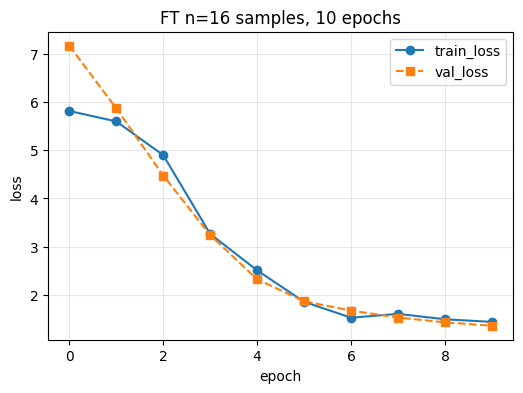

checkpoints/gridsfm_open_v1.1.pt: metadata.arch missing; building model from default hyperparameters. If the release was trained with non-default arch, the load will silently shape-adapt every layer.


      FT n=16  fulltop  cost_mape=  0.97%  pg_mae=0.0668  qg_mae=0.1705  V_mae=0.0188  theta_mae=0.0547  brP_mae=0.0657  brQ_mae=0.1437  kcl_P=0.0003  kcl_Q=0.0011  therm_max=1.392  over=0.35%  n=750
          FT n=16  n-1  cost_mape=  0.95%  pg_mae=0.0641  qg_mae=0.1688  V_mae=0.0188  theta_mae=0.0552  brP_mae=0.0645  brQ_mae=0.1435  kcl_P=0.0003  kcl_Q=0.0011  therm_max=1.388  over=0.34%  n=750


In [8]:
log_16, state_16 = run_ft(n_samples=16, epochs=10)
plot_losses(log_16, 'FT n=16 samples, 10 epochs')
plt.show()
ft16_ft, ft16_n1 = eval_state(state_16)
print(fmt_eval('FT n=16  fulltop', ft16_ft))
print(fmt_eval('FT n=16  n-1',     ft16_n1))

## 9. FT round 2: n_train = 104 (13 batches × bs=8)

checkpoints/gridsfm_open_v1.1.pt: metadata.arch missing; building model from default hyperparameters. If the release was trained with non-default arch, the load will silently shape-adapt every layer.


[ft n=104] 10 epochs, batch_size=8


  ep 00  train_loss=3.6785  val_loss=1.7198  val_cost_mape=1.61%  t=22s


  ep 01  train_loss=1.4077  val_loss=1.2068  val_cost_mape=1.63%  t=96s


  ep 02  train_loss=1.0590  val_loss=0.9954  val_cost_mape=0.94%  t=170s


...

  ep 05  train_loss=0.6716  val_loss=0.6875  val_cost_mape=1.51%  t=394s


  ep 06  train_loss=0.6811  val_loss=0.6511  val_cost_mape=1.34%  t=468s


  ep 07  train_loss=0.6199  val_loss=0.6166  val_cost_mape=1.38%  t=542s


  ep 08  train_loss=0.6323  val_loss=0.5852  val_cost_mape=1.23%  t=616s


  ep 09  train_loss=0.5876  val_loss=0.5596  val_cost_mape=1.50%  t=690s


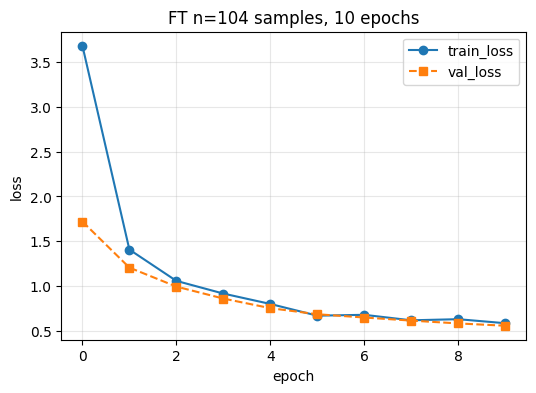

checkpoints/gridsfm_open_v1.1.pt: metadata.arch missing; building model from default hyperparameters. If the release was trained with non-default arch, the load will silently shape-adapt every layer.


      FT n=104 fulltop  cost_mape=  1.36%  pg_mae=0.0531  qg_mae=0.1004  V_mae=0.0092  theta_mae=0.0468  brP_mae=0.0588  brQ_mae=0.0989  kcl_P=0.0003  kcl_Q=0.0013  therm_max=1.211  over=0.20%  n=750
          FT n=104 n-1  cost_mape=  1.38%  pg_mae=0.0508  qg_mae=0.0997  V_mae=0.0091  theta_mae=0.0477  brP_mae=0.0578  brQ_mae=0.0990  kcl_P=0.0003  kcl_Q=0.0013  therm_max=1.209  over=0.19%  n=750


In [9]:
log_104, state_104 = run_ft(n_samples=104, epochs=10)
plot_losses(log_104, 'FT n=104 samples, 10 epochs')
plt.show()
ft104_ft, ft104_n1 = eval_state(state_104)
print(fmt_eval('FT n=104 fulltop', ft104_ft))
print(fmt_eval('FT n=104 n-1',     ft104_n1))

## 10. FT round 3: n_train = 1000 (125 batches × bs=8)

checkpoints/gridsfm_open_v1.1.pt: metadata.arch missing; building model from default hyperparameters. If the release was trained with non-default arch, the load will silently shape-adapt every layer.


[ft n=1000] 10 epochs, batch_size=8


  ep 00  train_loss=1.1159  val_loss=0.5749  val_cost_mape=1.46%  t=202s


  ep 01  train_loss=0.5181  val_loss=0.4721  val_cost_mape=2.14%  t=455s


  ep 02  train_loss=0.4520  val_loss=0.4358  val_cost_mape=1.17%  t=709s


...

  ep 05  train_loss=0.4002  val_loss=0.4085  val_cost_mape=1.63%  t=1470s


  ep 06  train_loss=0.4009  val_loss=0.4297  val_cost_mape=2.16%  t=1723s


  ep 07  train_loss=0.3899  val_loss=0.3965  val_cost_mape=1.40%  t=1978s


  ep 08  train_loss=0.4031  val_loss=0.3959  val_cost_mape=1.25%  t=2231s


  ep 09  train_loss=0.3906  val_loss=0.3924  val_cost_mape=1.47%  t=2487s


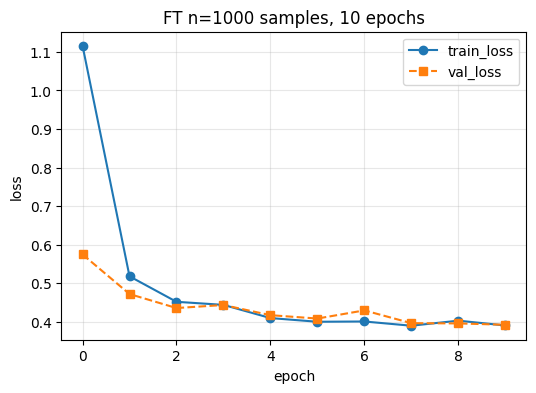

checkpoints/gridsfm_open_v1.1.pt: metadata.arch missing; building model from default hyperparameters. If the release was trained with non-default arch, the load will silently shape-adapt every layer.


     FT n=1000 fulltop  cost_mape=  1.32%  pg_mae=0.0487  qg_mae=0.0858  V_mae=0.0050  theta_mae=0.0448  brP_mae=0.0482  brQ_mae=0.0499  kcl_P=0.0003  kcl_Q=0.0007  therm_max=1.091  over=0.11%  n=750
         FT n=1000 n-1  cost_mape=  1.35%  pg_mae=0.0465  qg_mae=0.0852  V_mae=0.0050  theta_mae=0.0459  brP_mae=0.0473  brQ_mae=0.0505  kcl_P=0.0003  kcl_Q=0.0007  therm_max=1.089  over=0.11%  n=750


In [10]:
log_1000, state_1000 = run_ft(n_samples=1000, epochs=10)
plot_losses(log_1000, 'FT n=1000 samples, 10 epochs')
plt.show()
ft1000_ft, ft1000_n1 = eval_state(state_1000)
print(fmt_eval('FT n=1000 fulltop', ft1000_ft))
print(fmt_eval('FT n=1000 n-1',     ft1000_n1))

## 11. Combined loss curves and summary

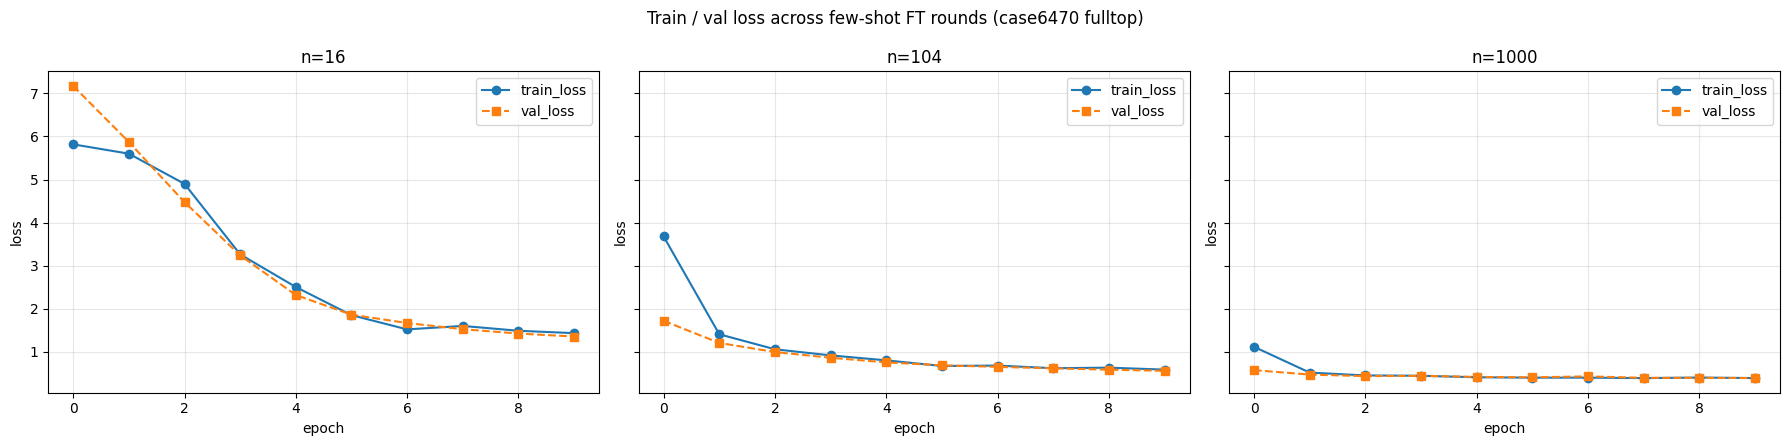

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)
plot_losses(log_16,   'n=16',   ax=axes[0])
plot_losses(log_104,  'n=104',  ax=axes[1])
plot_losses(log_1000, 'n=1000', ax=axes[2])
fig.suptitle('Train / val loss across few-shot FT rounds (case6470 fulltop)')
plt.tight_layout(); plt.show()

In [12]:
rows = [
    ('0-shot',    zeroshot_ft, zeroshot_n1),
    ('FT n=16',   ft16_ft,     ft16_n1),
    ('FT n=104',  ft104_ft,    ft104_n1),
    ('FT n=1000', ft1000_ft,   ft1000_n1),
]
cols = ['cost_mape', 'pg_mae', 'qg_mae', 'V_mae', 'theta_mae',
        'brP_mae', 'brQ_mae', 'kcl_P_resid', 'kcl_Q_resid',
        'thermal_max_loading', 'thermal_frac_overload']
hdr_fields = [f'{c:>10}' if c != 'cost_mape' else f'{"cost_mape":>10}' for c in cols]
hdr = f'{"round":<12}  {"split":<8}  ' + '  '.join(hdr_fields)
print(hdr); print('-' * len(hdr))

def _fmt(c, v):
    if c == 'cost_mape' or c == 'thermal_frac_overload':
        return f'{v*100:9.2f}%'
    if c == 'thermal_max_loading':
        return f'{v:10.3f}'
    return f'{v:10.4f}'

for name, ft, n1 in rows:
    for split_name, m in [('fulltop', ft), ('n-1', n1)]:
        cells = '  '.join(_fmt(c, m[c]) for c in cols)
        print(f'{name:<12}  {split_name:<8}  {cells}')

round         split      cost_mape      pg_mae      qg_mae       V_mae   theta_mae     brP_mae     brQ_mae  kcl_P_resid  kcl_Q_resid  thermal_max_loading  thermal_frac_overload
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
0-shot        fulltop        2.43%      0.0961      0.2320      0.0219      0.0496      0.0716      0.1691      0.0003      0.0015       3.917       0.38%
0-shot        n-1            2.47%      0.0937      0.2303      0.0219      0.0505      0.0712      0.1689      0.0003      0.0015       3.917       0.38%
FT n=16       fulltop        0.97%      0.0668      0.1705      0.0188      0.0547      0.0657      0.1437      0.0003      0.0011       1.392       0.35%
FT n=16       n-1            0.95%      0.0641      0.1688      0.0188      0.0552      0.0645      0.1435      0.0003      0.0011       1.388       0.34%
FT n=104      fulltop     